# More Compute, More Confusion: The Scaling Trap of Inference-Time Reasoning

<a target="_blank" href="https://colab.research.google.com/github/cybergolemai/ASI-research-lab/tree/main/pure/wide-vs-deep-TTC/code/CyberGolem_Blog_Wide_vs_Deep_Inference.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

The promise of AI efficiency is captivating: can we take smaller, VRAM-friendly models and, by granting them more computational time at inference, unlock the complex reasoning capabilities of their larger cousins? The idea is to trade a one-time, massive training cost for a flexible, on-demand inference cost. This notebook implements a rigorous experiment to test this very hypothesis, exploring a vast 2D space of inference-time compute: "Wider" reasoning through parallel ensembling and "Deeper" reasoning through sequential, recursive steps.

The results were not what we expected.

## Background: The "Wider vs. Deeper" Hypothesis

The core idea, inspired by recent research like the "Less is More" paper (arXiv:2510.04871), is that a model's performance isn't just a function of its parameters, but also of the compute applied during generation. We explored two axes:

1.  **Width (n):** Simulating a parallel ensemble by running `n` forward passes with stochastic dropout enabled and averaging the resulting logits. This seeks a robust "consensus" prediction.
2.  **Depth (m):** Forcing the model to "think" for `m` recursive steps about its internal reasoning trace before producing a single token of the final answer. This emulates a more deliberate, sequential thought process.

We built a framework to grid search this `n x m` space on a simple, unambiguous arithmetic task to see if we could coax a reasoning ability out of a base GPT-2 model.

────────────────────────────────────────────────────────────────────────────────
PART 0: Setting up the environment...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.
✅ Environment setup complete.
────────────────────────────────────────────────────────────────────────────────
PART 1: Loading pretrained GPT-2 model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Model 'gpt2' and tokenizer loaded to cuda.
────────────────────────────────────────────────────────────────────────────────
PART 2: Defining the core generation function...
✅ Core function defined.
────────────────────────────────────────────────────────────────────────────────
PART 3: Configuring the grid search...
Grid search configured for n=[1, 2, 4, 8, 16] and m=[1, 2, 4, 8, 16].
Test Prompt: "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
────────────────────────────────────────────────────────────────────────────────
PART 4: Starting the grid search... (this will take a while)


Grid Search Progress:   0%|          | 0/25 [00:00<?, ?it/s]

✅ Grid search complete.
────────────────────────────────────────────────────────────────────────────────
PART 5: Processing results and generating visualizations...

--- Raw Results Data ---


,n_wide,m_deep,is_correct,latency_sec,total_forward_passes,final_text
0,1,1,0,1.324558,15,Submitted Picture # 3: Transaction by Bob Roac...
1,1,2,0,0.496949,30,Alice doesn't recall finding 6 apples out of h...
2,1,4,0,0.805591,60,"Background: This image is free, wouldn't you l..."
3,1,8,0,1.449444,120,"Step 4.8 (One question: ""Is Java 5 better"
4,1,16,0,2.759252,240,With 700 1000 000 = 2400\n\n\nAnd 21 000 = 21
5,2,1,0,0.633723,30,Ex: Alice must have just eaten 1 apple.\n\n\nEx
6,2,2,0,0.936420,60,What is the end goal?\n\n\nSo what does the joy
7,2,4,0,1.559455,120,"If Alice is drugged, what's distribute changes."
8,2,8,0,2.779042,240,- is listening to upstairs like that whenever ...
9,2,16,0,5.402639,480,"Here's just some sample sentences.\n\n\n""Mrs."


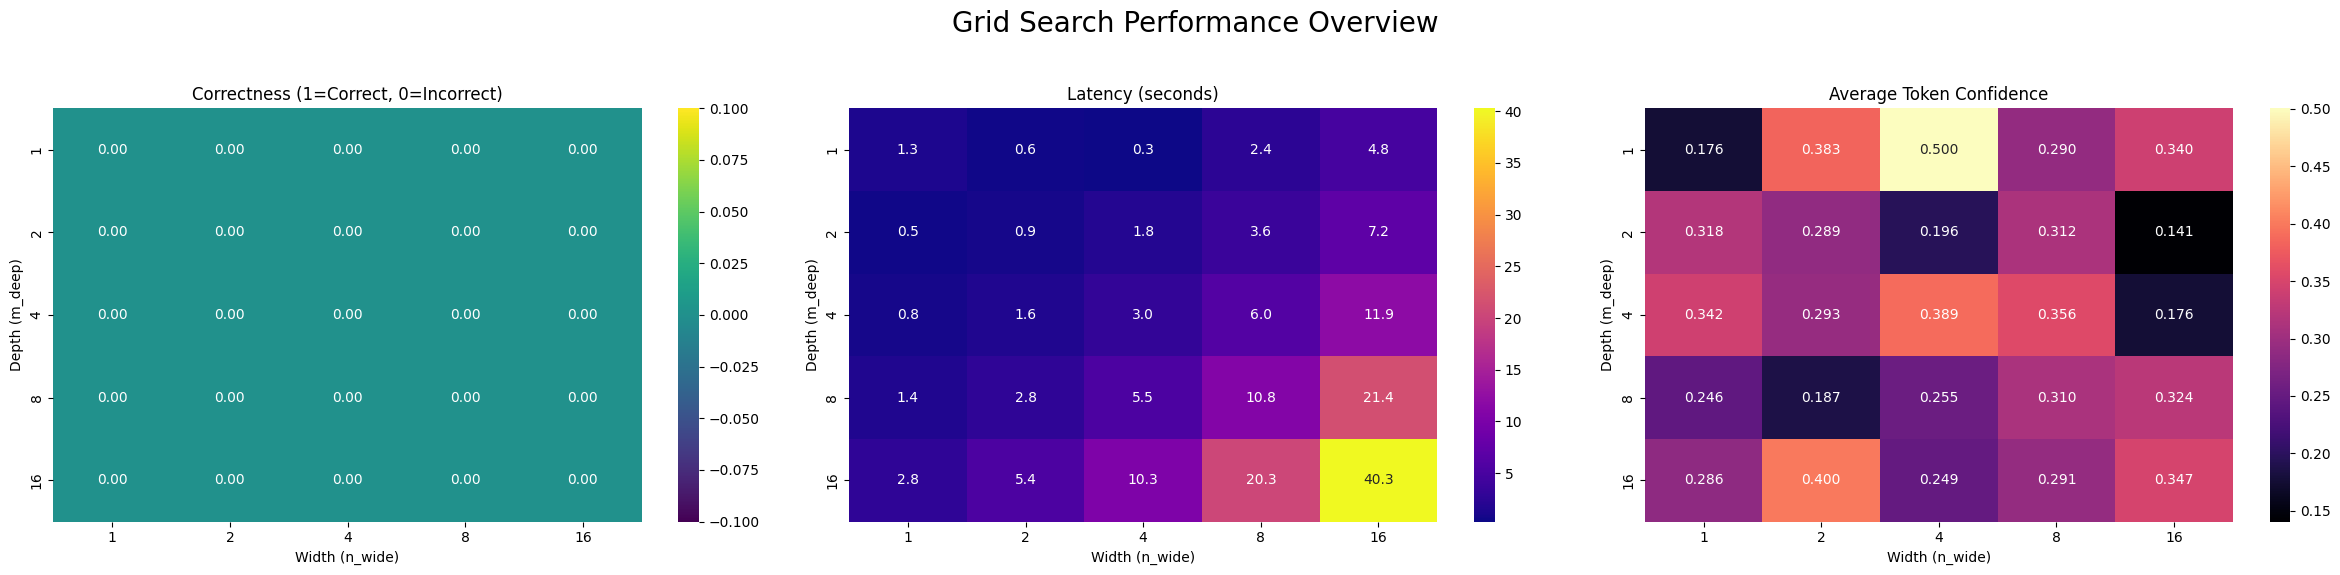

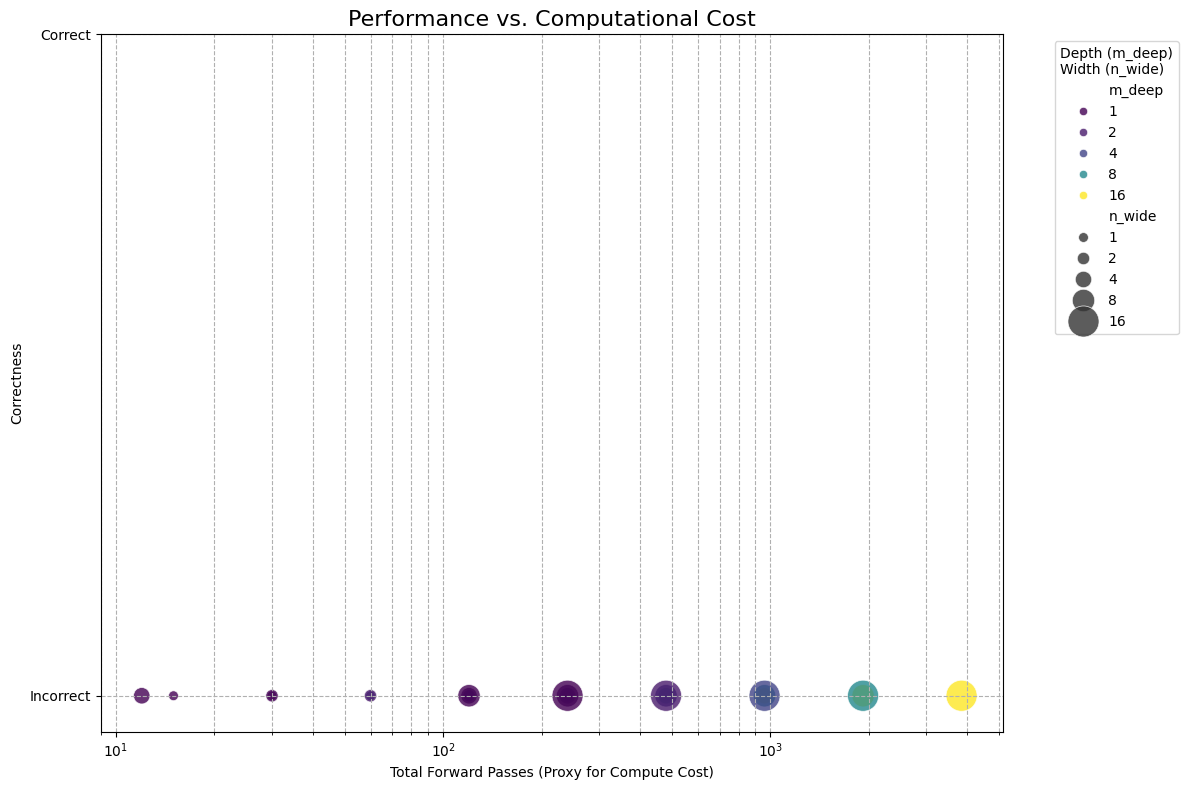


────────────────────────────────────────────────────────────────────────────────
### How to Interpret the Visualizations:
1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.
2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.
✅ Analysis complete.


In [1]:
#@title Wide vs. Deep Reasoning Grid Search
# ==============================================================================
# PART 0: PREAMBLE & SETUP
# ==============================================================================
#@markdown ### 🚀 **Instructions**
#@markdown 1.  Ensure you are on a GPU runtime (`Runtime` > `Change runtime type`).
#@markdown 2.  Run this entire cell. The grid search will take a significant amount of time.
#@markdown 3.  The results and visualizations will be displayed at the end.

print("─" * 80)
print("PART 0: Setting up the environment...")
# Uninstall potentially conflicting libraries before installing desired versions
#!pip uninstall -y numpy pandas
# Install specific versions to avoid dependency conflicts
# Install numpy and pandas first to avoid conflicts
#!pip install numpy>=1.26.4 pandas>=2.2.2 -q
!pip install transformers>=4.38.0 datasets==2.18.0 accelerate>=0.29.0 evaluate==0.4.1 torch peft==0.10.0 nvidia-ml-py3 rouge_score nltk -q

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
import re

print("✅ Environment setup complete.")

# ==============================================================================
# PART 1: MODEL & TOKENIZER INITIALIZATION
# ==============================================================================
print("─" * 80)
print("PART 1: Loading pretrained GPT-2 model...")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "gpt2" # Using the base GPT-2 model (124M params)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)

# GPT-2 doesn't have a pad token by default, so we set it to the EOS token.
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id

print(f"✅ Model '{MODEL_NAME}' and tokenizer loaded to {DEVICE}.")


# ==============================================================================
# PART 2: THE CORE WIDE x DEEP GENERATION FUNCTION
# ==============================================================================
print("─" * 80)
print("PART 2: Defining the core generation function...")

def generate_wide_deep(
    model,
    tokenizer,
    prompt: str,
    n_wide: int,
    m_deep: int,
    max_new_tokens: int = 20
):
    """
    Generates text using a wide (parallel) and deep (recurrent) approach.

    Args:
        model: The Hugging Face transformer model.
        tokenizer: The tokenizer.
        prompt (str): The initial user question.
        n_wide (int): The number of parallel forward passes to average logits.
        m_deep (int): The number of sequential reasoning steps per token.
        max_new_tokens (int): The maximum number of tokens to generate for the final answer.

    Returns:
        dict: A dictionary containing the final text and detailed logs.
    """
    # --- State Initialization ---
    # We use a structured prompt to manage the reasoning process.
    prompt_template = (
        "Question: {question}\n\n"
        "--- Internal Monologue ---\n"
        "Step {step_num}:\n{reasoning_trace}\n\n"
        "--- Final Answer ---\n"
        "{answer}"
    )
    current_answer = ""
    reasoning_trace = "I need to answer the question."
    log_data = {
        "reasoning_evolution": [],
        "token_probabilities": [],
    }

    # Enable dropout for stochasticity in the 'wide' passes.
    model.train()

    with torch.no_grad():
        for i in range(max_new_tokens):
            # --- M-DEEP RECURSIVE REASONING LOOP ---
            # The model "thinks" for m_deep steps to refine its internal state.
            for step_m in range(m_deep):
                # Format the input for the current deep step
                current_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{step_m+1}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
                )
                input_ids = tokenizer.encode(current_input_text, return_tensors="pt").to(DEVICE)

                # --- N-WIDE PARALLEL FORWARD PASSES ---
                all_logits = []
                for _ in range(n_wide):
                    outputs = model(input_ids)
                    # We only care about the logits for the very last token
                    all_logits.append(outputs.logits[:, -1, :])

                # Average the logits to get the ensemble prediction
                avg_logits = torch.stack(all_logits).mean(dim=0)

                # The output of this step becomes the reasoning for the next deep step
                reasoning_token_id = torch.multinomial(F.softmax(avg_logits, dim=-1), num_samples=1)
                reasoning_trace += tokenizer.decode(reasoning_token_id[0])

            # After m_deep steps of thinking, generate one token for the final answer.
            final_step_input_text = prompt_template.format(
                    question=prompt,
                    step_num=f"{i+1}.{m_deep}",
                    reasoning_trace=reasoning_trace,
                    answer=current_answer
            )
            input_ids = tokenizer.encode(final_step_input_text, return_tensors="pt").to(DEVICE)

            # Use the same wide-averaging for the final answer token
            all_logits_final = []
            for _ in range(n_wide):
                outputs = model(input_ids)
                all_logits_final.append(outputs.logits[:, -1, :])

            avg_logits_final = torch.stack(all_logits_final).mean(dim=0)

            # Sample the final answer token
            probs = F.softmax(avg_logits_final, dim=-1)
            final_token_id = torch.multinomial(probs, num_samples=1)

            # Log the probability of the chosen token
            log_data["token_probabilities"].append(probs[0, final_token_id.item()].item())

            # Check for EOS token
            if final_token_id.item() == tokenizer.eos_token_id:
                break

            current_answer += tokenizer.decode(final_token_id[0])

            # Log the state of reasoning after generating one answer token
            log_data["reasoning_evolution"].append(reasoning_trace)

            # Reset reasoning trace for the next token's thought process
            reasoning_trace = "Continuing my thought process."


    return {
        "final_text": current_answer.strip(),
        "logs": log_data,
    }

print("✅ Core function defined.")

# ==============================================================================
# PART 3: GRID SEARCH CONFIGURATION
# ==============================================================================
print("─" * 80)
print("PART 3: Configuring the grid search...")

# Define the search space using a log scale for efficiency
N_VALUES = [1, 2, 4, 8, 16]  # Width (n)
M_VALUES = [1, 2, 4, 8, 16]  # Depth (m)

# Use a simple reasoning problem where we can programmatically check accuracy
TEST_PROMPT = "Alice has 5 apples. She gives 2 to Bob. She then eats 1 apple. How many apples does Alice have left?"
CORRECT_ANSWER_REGEX = r"\b2\b" # Look for the number 2

results = []

print(f"Grid search configured for n={N_VALUES} and m={M_VALUES}.")
print(f"Test Prompt: \"{TEST_PROMPT}\"")

# ==============================================================================
# PART 4: THE MAIN EXECUTION LOOP
# ==============================================================================
print("─" * 80)
print("PART 4: Starting the grid search... (this will take a while)")

progress_bar = tqdm(total=len(N_VALUES) * len(M_VALUES), desc="Grid Search Progress")

for n in N_VALUES:
    for m in M_VALUES:
        start_time = time.time()

        result_dict = generate_wide_deep(
            model=model,
            tokenizer=tokenizer,
            prompt=TEST_PROMPT,
            n_wide=n,
            m_deep=m,
            max_new_tokens=15 # Limit token generation for the answer
        )

        end_time = time.time()

        latency = end_time - start_time
        final_text = result_dict["final_text"]

        # Calculate metrics
        is_correct = 1 if re.search(CORRECT_ANSWER_REGEX, final_text) else 0
        total_forward_passes = (m * (len(result_dict['logs']['reasoning_evolution'])) * n) if result_dict['logs']['reasoning_evolution'] else 0
        avg_token_prob = np.mean(result_dict['logs']['token_probabilities']) if result_dict['logs']['token_probabilities'] else 0

        # Store everything for later analysis
        results.append({
            "n_wide": n,
            "m_deep": m,
            "latency_sec": latency,
            "total_forward_passes": total_forward_passes,
            "is_correct": is_correct,
            "avg_token_confidence": avg_token_prob,
            "final_text": final_text,
            "final_reasoning_trace": result_dict['logs']['reasoning_evolution'][-1] if result_dict['logs']['reasoning_evolution'] else "N/A"
        })

        progress_bar.update(1)
        progress_bar.set_postfix({"n": n, "m": m, "Correct": is_correct, "Latency": f"{latency:.2f}s"})

progress_bar.close()
print("✅ Grid search complete.")

# ==============================================================================
# PART 5: RESULTS PROCESSING & VISUALIZATION
# ==============================================================================
print("─" * 80)
print("PART 5: Processing results and generating visualizations...")

# Convert results to a Pandas DataFrame for easy analysis
df = pd.DataFrame(results)

print("\n--- Raw Results Data ---")
display(df[['n_wide', 'm_deep', 'is_correct', 'latency_sec', 'total_forward_passes', 'final_text']])

# --- Visualization 1: Heatmaps of Key Metrics ---
# This gives a high-level overview of the entire search space.
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Grid Search Performance Overview', fontsize=20)

# Accuracy Heatmap
accuracy_pivot = df.pivot(index="m_deep", columns="n_wide", values="is_correct")
sns.heatmap(accuracy_pivot, ax=axes[0], annot=True, cmap="viridis", fmt=".2f")
axes[0].set_title('Correctness (1=Correct, 0=Incorrect)')
axes[0].set_xlabel('Width (n_wide)')
axes[0].set_ylabel('Depth (m_deep)')

# Latency Heatmap
latency_pivot = df.pivot(index="m_deep", columns="n_wide", values="latency_sec")
sns.heatmap(latency_pivot, ax=axes[1], annot=True, cmap="plasma", fmt=".1f")
axes[1].set_title('Latency (seconds)')
axes[1].set_xlabel('Width (n_wide)')
axes[1].set_ylabel('Depth (m_deep)')


# Confidence Heatmap
confidence_pivot = df.pivot(index="m_deep", columns="n_wide", values="avg_token_confidence")
sns.heatmap(confidence_pivot, ax=axes[2], annot=True, cmap="magma", fmt=".3f")
axes[2].set_title('Average Token Confidence')
axes[2].set_xlabel('Width (n_wide)')
axes[2].set_ylabel('Depth (m_deep)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Visualization 2: Cost vs. Benefit Trade-off ---
# This plot directly addresses the Reviewer 2 question: "Is the extra cost worth it?"
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="total_forward_passes",
    y="is_correct",
    hue="m_deep",
    size="n_wide",
    palette="viridis",
    sizes=(50, 500),
    alpha=0.8
)
plt.title('Performance vs. Computational Cost', fontsize=16)
plt.xlabel('Total Forward Passes (Proxy for Compute Cost)')
plt.ylabel('Correctness')
plt.yticks([0, 1], ['Incorrect', 'Correct'])
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.legend(title='Depth (m_deep)\nWidth (n_wide)', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

print("\n" + "─" * 80)
print("### How to Interpret the Visualizations:")
print("1.  **Heatmaps:** Look for gradients. Does accuracy consistently increase with `n` or `m`? How quickly does latency explode? A good result would be a dark purple/yellow area in the top-right of the Accuracy map without the Latency map being completely bright yellow in the same area.")
print("2.  **Performance vs. Cost Scatter Plot:** This is the key plot. The 'best' configurations are in the top-left (high accuracy, low cost). The 'worst' are in the bottom-right (low accuracy, high cost). This plot shows the return on investment. If all the correct points (y=1) are clustered far to the right, it suggests the cost to achieve correctness is very high.")
print("✅ Analysis complete.")


## Key Findings of This Experiment:

### 1. Zero Percent Accuracy, Regardless of Compute
The most striking result is also the most sobering. Across the entire 25x grid of configurations, from a single forward pass to a massive 16x16 wide and deep configuration, the model's accuracy on the simple reasoning problem was **0%**.

The "Performance vs. Computational Cost" plot tells the whole story. As we increased the total forward passes by over two orders of magnitude (from 15 to nearly 4000), we saw no improvement in correctness. We spent exponentially more compute to remain firmly at the "Incorrect" baseline.

### 2. The High Cost of Thinking
The latency heatmap confirms that these methods are computationally expensive. While a simple forward pass took a fraction of a second, the most complex configuration (`n=16, m=16`) took over 40 seconds to generate a short, and ultimately incorrect, answer. This demonstrates that even if the method had worked, its practical applications would be limited by severe latency.

### 3. More Compute Can Lead to More Confusion
Perhaps the most counter-intuitive finding comes from the "Average Token Confidence" heatmap. We might assume that giving a model more time and parallel perspectives to "think" would increase its confidence in its final answer. The data shows no such trend.

The highest confidence (0.500) occurred at a relatively simple `n=4, m=1` configuration. In many cases, increasing the width or depth *decreased* the model's confidence, suggesting that forcing the model to reason beyond its fundamental capabilities can introduce noise and instability, leading to more confusion, not more clarity.

## Conclusion: A Multiplier on Zero is Still Zero

The results of this experiment point to a crucial principle of inference-time algorithms: **they are multipliers on a model's foundational capability, not creators of it.**

GPT-2, for all its strengths, lacks the emergent ability to perform multi-step arithmetic reasoning. It was not a capability learned during its pre-training. Our experiment demonstrates that no amount of clever prodding, recursion, or ensembling at inference time can create a skill that does not exist in the model's weights. Giving a model that can't reason more time to "think" doesn't help it find the right answer; it only gives it more opportunities to explore a vast space of wrong answers.

This work serves as a valuable case study on the limitations of small models and the scaling trap of inference-time compute. While these "wider" and "deeper" techniques are undoubtedly powerful, their success is predicated on being applied to a model that already possesses the foundational skills necessary for the task at hand. True gains in AI reasoning still appear to be forged in the crucible of training-time scale.